# Midterm Project
### Computational Ordinary Differential Equations

## 1. Computer Problem 9.8 (Heath)

**(a)** No — a differential equation by itself does not generally determine a unique solution. A given ODE can have infinitely many solutions. For example, the simple ODE $\dot{y} = y$ has the general solution $y(t) = Ce^{t}$ for any constant $C$, so without fixing $C$ we have a whole family of curves that all satisfy the equation.

**(b)** To pin down a unique solution, we need to supply **initial conditions** (or more generally, boundary conditions). For a first-order ODE, specifying the value of the solution at some starting point $t_0$ — i.e., $y(t_0) = y_0$ — is enough to determine a unique solution (assuming the ODE satisfies the conditions of the existence and uniqueness theorem, such as Lipschitz continuity of the right-hand side). This combination of an ODE together with an initial condition is called an **initial value problem (IVP)**.

For a system of $n$ first-order ODEs (or equivalently an $n$th-order ODE rewritten as a system), we need $n$ initial conditions — one for each component of the state vector — to uniquely determine the solution.

---
## 2. Hitting a Target with the 16-inch Guns of the U.S.S. Missouri

We model a projectile fired from the 16-inch/50-caliber Mark 7 gun, using data from the [Wikipedia page](https://en.wikipedia.org/wiki/16-inch/50-caliber_Mark_7_gun). Air resistance is proportional to velocity squared, and we ignore crosswinds, so the motion stays in the $(x, y)$ plane.

**Equation of motion:**

$$\ddot{\mathbf{x}} = -g\begin{pmatrix}0\\1\end{pmatrix} - \alpha\, v\, \mathbf{v}$$

where $\mathbf{x} = (x, y)$, $\mathbf{v} = (\dot{x}, \dot{y})$, $v = \|\mathbf{v}\|$, and $\alpha = k/m$.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

### Part A — Setting Up the Model

We rewrite the second-order ODE as a system of four first-order ODEs by introducing the state vector $\mathbf{s} = [x,\, y,\, v_x,\, v_y]$:

$$\frac{d}{dt}\begin{pmatrix}x \\ y \\ v_x \\ v_y\end{pmatrix} = \begin{pmatrix}v_x \\ v_y \\ -\alpha\, v\, v_x \\ -g - \alpha\, v\, v_y\end{pmatrix}$$

with initial conditions $x(0) = 0$, $y(0) = 0$, $v_x(0) = v_0\cos\theta$, $v_y(0) = v_0\sin\theta$.

In [2]:
# Physical constants
g = 9.81  # gravitational acceleration (m/s^2)

# Gun / shell parameters (HC Mark 13)
v0 = 820.0       # muzzle velocity (m/s)
max_range = 39e3  # maximum range of gun (39 km, in meters)

# Target parameters
x_target = 10 * 1609.344   # 10 miles in meters
y_target = 300 * 0.3048    # 300 feet in meters

print(f"Target distance: {x_target:.1f} m ({x_target/1000:.2f} km)")
print(f"Target altitude: {y_target:.2f} m")

Target distance: 16093.4 m (16.09 km)
Target altitude: 91.44 m


In [3]:
def projectile_ode(t, state, alpha):
    """Right-hand side of the projectile ODE system."""
    x, y, vx, vy = state
    v = np.sqrt(vx**2 + vy**2)  # speed
    
    dxdt = vx
    dydt = vy
    dvxdt = -alpha * v * vx       # drag in x
    dvydt = -g - alpha * v * vy   # gravity + drag in y
    
    return [dxdt, dydt, dvxdt, dvydt]

In [4]:
def simulate(theta, alpha, v0=820.0, t_max=300.0):
    """
    Simulate a projectile trajectory.
    
    Parameters:
        theta : launch angle in radians
        alpha : drag coefficient (k/m)
        v0    : muzzle velocity (m/s)
        t_max : maximum simulation time (s)
    
    Returns:
        sol : ODE solution object
    """
    # initial conditions
    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)
    state0 = [0.0, 0.0, vx0, vy0]
    
    # event: projectile hits the ground (y = 0 on the way down)
    def hit_ground(t, state, alpha):
        return state[1]
    hit_ground.terminal = True
    hit_ground.direction = -1  # only trigger when y is decreasing
    
    sol = solve_ivp(
        projectile_ode, [0, t_max], state0,
        args=(alpha,),
        events=hit_ground,
        dense_output=True,
        max_step=0.5,
        rtol=1e-10,
        atol=1e-12
    )
    return sol

### Part B — Determining the Drag Coefficient $\alpha$

We are told that the maximum range is 39 km when firing the HC Mark 13 shell at 45° elevation with muzzle velocity 820 m/s, and the target is at sea level. We use this to calibrate $\alpha$: we search for the value of $\alpha$ such that the simulated range at $\theta = 45°$ equals exactly 39 km.

This is a one-dimensional root-finding problem: find $\alpha$ such that $R(\alpha) - 39{,}000 = 0$, where $R(\alpha)$ is the simulated range. Since $R$ decreases monotonically with $\alpha$ (more drag $\Rightarrow$ shorter range), we just need to bracket the root and then use `brentq` to zero in on it.

In [5]:
def compute_range(alpha, theta=np.radians(45)):
    """Compute the ground-level range for a given alpha and launch angle."""
    sol = simulate(theta, alpha)
    # the terminal event gives us the landing point
    if len(sol.y_events[0]) > 0:
        return sol.y_events[0][0][0]  # x-coordinate at landing
    else:
        # if event didn't trigger, use the last x value
        return sol.y[0][-1]

def range_residual(alpha):
    """Residual function for root-finding: R(alpha) - 39000."""
    return compute_range(alpha) - max_range

In [6]:
# Quick check: what is the range with no drag vs. heavy drag?
# No drag (alpha ~ 0): range = v0^2 / g ~ 68.5 km (way more than 39 km)
# So alpha must be positive to reduce range to 39 km.

# Check signs of residual at bracket endpoints
r_low = range_residual(1e-6)   # very little drag -> long range -> positive
r_high = range_residual(0.01)  # lots of drag -> short range -> negative
print(f"Residual at alpha=1e-6: {r_low:.1f} m")
print(f"Residual at alpha=0.01: {r_high:.1f} m")
print(f"Sign change confirmed: root exists in this interval.")

Residual at alpha=1e-6: 26084.0 m
Residual at alpha=0.01: -38668.6 m
Sign change confirmed: root exists in this interval.


In [7]:
# Solve for alpha using Brent's method
alpha = brentq(range_residual, 1e-6, 0.01, xtol=1e-12)
print(f"Drag coefficient: alpha = {alpha:.6e} (1/m)")

# Verify
actual_range = compute_range(alpha)
print(f"Simulated range at 45°: {actual_range:.2f} m = {actual_range/1000:.4f} km")

Drag coefficient: alpha = 1.596065e-05 (1/m)
Simulated range at 45°: 39000.00 m = 39.0000 km


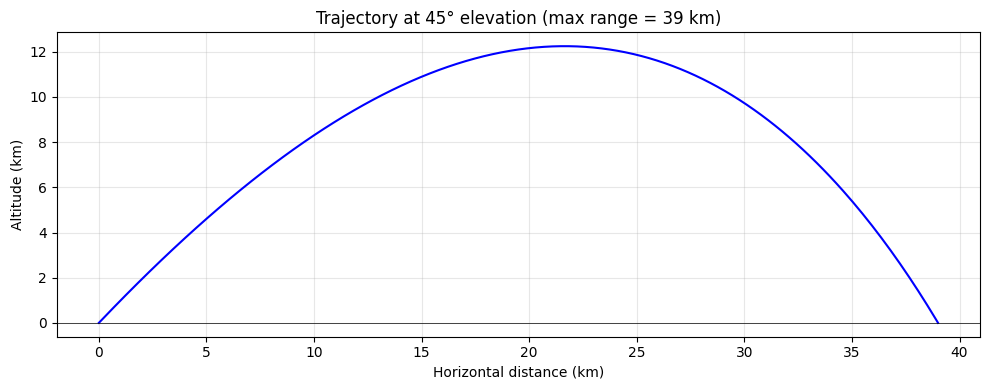

In [8]:
# Plot the trajectory at 45° to verify it looks reasonable
sol_45 = simulate(np.radians(45), alpha)

plt.figure(figsize=(10, 4))
plt.plot(sol_45.y[0] / 1000, sol_45.y[1] / 1000, 'b-')
plt.xlabel('Horizontal distance (km)')
plt.ylabel('Altitude (km)')
plt.title('Trajectory at 45° elevation (max range = 39 km)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

### Part C — Finding the Angle of Elevation to Hit the Target

The target is at a horizontal distance of 10 miles ($\approx 16{,}093$ m) and an altitude of 300 feet ($\approx 91.44$ m). We need to find the launch angle $\theta$ such that the trajectory passes through the point $(x_{\text{target}},\, y_{\text{target}})$.

**Approach:** For a given angle $\theta$, we simulate the trajectory and interpolate to find the altitude $y$ at horizontal position $x = x_{\text{target}}$. The residual is $y(x_{\text{target}}) - y_{\text{target}}$, and we look for the angle that makes this zero.

In the absence of drag, there are typically two angles that hit a given target (a low arc and a high arc). With drag, this is not guaranteed — we scan over the full range of allowed angles and use root-finding on any sign changes we detect.

In [9]:
def altitude_at_target(theta):
    """
    For a given launch angle theta, simulate the trajectory and
    return the altitude at x = x_target (by interpolation).
    """
    sol = simulate(theta, alpha)
    x_traj = sol.y[0]
    y_traj = sol.y[1]
    
    # check if trajectory reaches x_target
    if x_traj[-1] < x_target:
        return -1e6  # didn't reach — return large negative
    
    # interpolate y at x = x_target
    y_at_target = np.interp(x_target, x_traj, y_traj)
    return y_at_target

def target_residual(theta):
    """Residual: y at x_target minus y_target."""
    return altitude_at_target(theta) - y_target

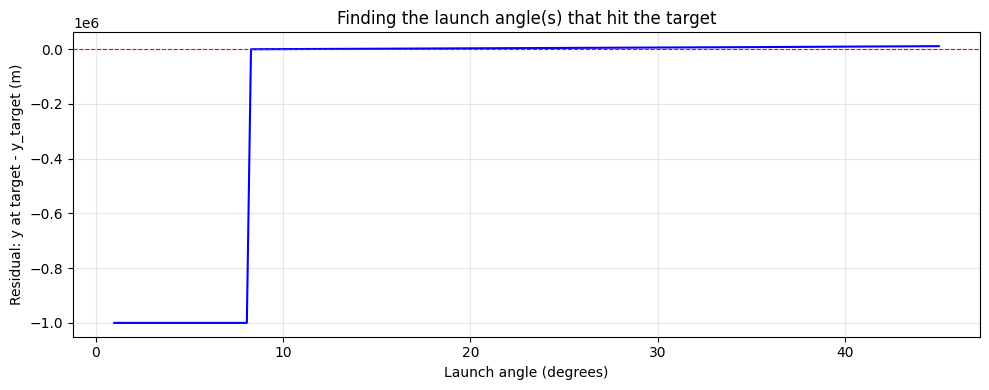

In [10]:
# Scan over a range of angles to see where sign changes occur
angles_deg = np.linspace(1, 45, 200)
residuals = [target_residual(np.radians(a)) for a in angles_deg]

plt.figure(figsize=(10, 4))
plt.plot(angles_deg, residuals, 'b-')
plt.axhline(y=0, color='r', linestyle='--', linewidth=0.8)
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Residual: y at target - y_target (m)')
plt.title('Finding the launch angle(s) that hit the target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Find sign changes to locate the roots
residuals = np.array(residuals)
sign_changes = []
for i in range(len(residuals) - 1):
    if residuals[i] * residuals[i+1] < 0:
        sign_changes.append((angles_deg[i], angles_deg[i+1]))

print(f"Found {len(sign_changes)} sign change(s):")
for lo, hi in sign_changes:
    print(f"  between {lo:.1f}° and {hi:.1f}°")

Found 1 sign change(s):
  between 8.3° and 8.5°


In [12]:
# Solve for each root using Brent's method
solutions = []
for lo, hi in sign_changes:
    theta_sol = brentq(target_residual, np.radians(lo), np.radians(hi), xtol=1e-12)
    solutions.append(theta_sol)
    deg = np.degrees(theta_sol)
    print(f"Solution: theta = {deg:.6f}°")

print(f"\nNumber of valid launch angles found: {len(solutions)}")

Solution: theta = 8.492540°

Number of valid launch angles found: 1


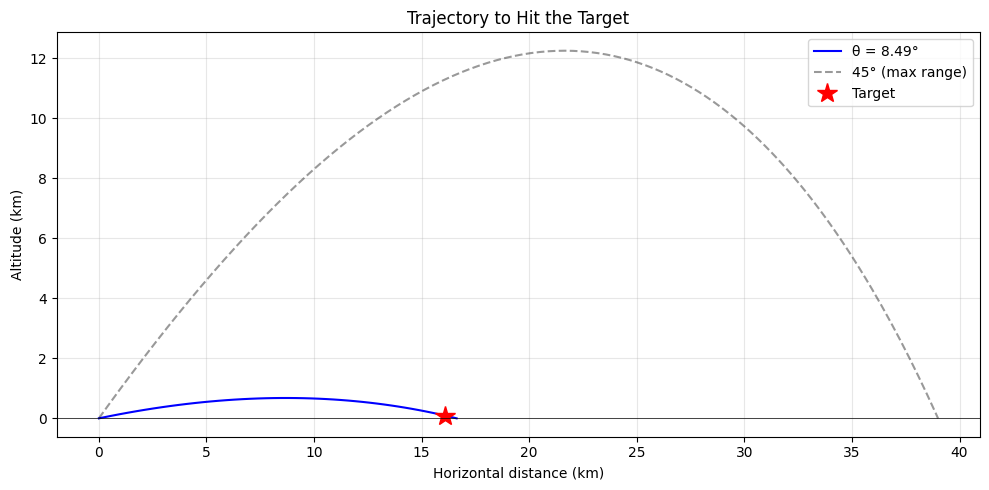

In [13]:
# Plot the solution trajectory with the target
plt.figure(figsize=(10, 5))

for i, theta_sol in enumerate(solutions):
    sol = simulate(theta_sol, alpha)
    label = f"θ = {np.degrees(theta_sol):.2f}°"
    plt.plot(sol.y[0] / 1000, sol.y[1] / 1000, 'b-', label=label)

# also show the 45° max-range trajectory for comparison
sol_45 = simulate(np.radians(45), alpha)
plt.plot(sol_45.y[0] / 1000, sol_45.y[1] / 1000, 'k--', alpha=0.4, label='45° (max range)')

# mark the target
plt.plot(x_target / 1000, y_target / 1000, 'r*', markersize=15, label='Target')

plt.xlabel('Horizontal distance (km)')
plt.ylabel('Altitude (km)')
plt.title('Trajectory to Hit the Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

In [14]:
# Summary of results
print("=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)
print(f"Drag coefficient:  alpha = {alpha:.6e} 1/m")
print(f"Target location:   x = {x_target:.1f} m, y = {y_target:.2f} m")
print(f"Muzzle velocity:   {v0} m/s")
print("-" * 55)
for i, theta_sol in enumerate(solutions):
    deg = np.degrees(theta_sol)
    print(f"Solution {i+1}:  theta = {deg:.6f}°")
print("=" * 55)

RESULTS SUMMARY
Drag coefficient:  alpha = 1.596065e-05 1/m
Target location:   x = 16093.4 m, y = 91.44 m
Muzzle velocity:   820.0 m/s
-------------------------------------------------------
Solution 1:  theta = 8.492540°


### Discussion

The scan over all allowed launch angles (1° to 45°) reveals only **one** solution at approximately **8.49°**. This makes physical sense: without air resistance, a target at 16 km would admit both a low-angle and a high-angle solution. However, with quadratic drag, the high-angle trajectories lose much more energy (the shell spends longer in the air at high speed), so at any angle above ~8.5° the shell is far above the target altitude when it passes over the target's horizontal position. The residual plot above confirms this — the residual is negative for very small angles (shell hits the ground before reaching the target) and stays positive for all angles above the solution.

The required elevation of roughly **8.5°** is well within the gun's maximum elevation of 45°.